# 04c — RoBERTa-base Deep Learning Baseline

**Goal**: Fine-tune `roberta-base` (125 M params) on the 10-class CFPB product classification task and compare against the TF-IDF + Logistic Regression baseline (Macro-F1 = 0.7543) and ModernBERT-base (NB04b).

**Why RoBERTa?** Originally planned DeBERTa-v3-base but it has a known bug that causes training to fail. RoBERTa-base is a robust, well-tested encoder that serves as a solid second deep-learning baseline:
- **Proven architecture**: Meta's optimised BERT pretraining recipe (dynamic masking, no NSP, larger batches, more data)
- **125 M parameters** — slightly smaller than ModernBERT-base (149 M), fits easily on 8 GB
- **512-token context** — standard length, sufficient for most complaints
- **fp16-safe** — unlike ModernBERT, no bf16 requirement; works with standard mixed-precision

**Hardware target**: NVIDIA RTX 4060 8 GB VRAM · 64 GB RAM · AMD Ryzen 7000 · Windows 11

**Windows-specific fixes applied**:
- `dataloader_num_workers=0` — Windows spawn multiprocessing freeze
- `use_reentrant=False` — PyTorch 2.x gradient checkpointing compatibility

| Setting | Value | Rationale |
|---|---|---|
| Model | `roberta-base` (125 M params) | Well-tested encoder, fits in 8 GB |
| Max tokens | 256 | Keeps VRAM safe; RoBERTa supports up to 512 |
| Batch size | 16 × 2 grad-accum = effective 32 | Same as ModernBERT notebook for fair comparison |
| Precision | **fp16** | Standard mixed-precision, RoBERTa handles it fine |
| Grad checkpointing | On (use_reentrant=False) | Keeps VRAM usage comfortable |

In [ ]:
# ─── One-time installs (restart kernel after first run) ───
# !pip install --upgrade transformers[torch] datasets accelerate evaluate scikit-learn --quiet
# !pip install sentencepiece protobuf --quiet

In [1]:
import os, sys, time, json, pickle, warnings, gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
from torch import nn
from torch.utils.data import Dataset

import transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
)

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

# ─── Reproducibility ───
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ─── Device check ───
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
    bf16_ok = torch.cuda.is_bf16_supported()
    print(f"GPU: {gpu_name}  ({gpu_mem:.1f} GB)  bf16={'✓' if bf16_ok else '✗'}")
else:
    print("⚠️  No GPU detected — training will be very slow")
    bf16_ok = False
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"OS: {sys.platform}")

GPU: NVIDIA GeForce RTX 4060 Laptop GPU  (8.0 GB)  bf16=✓
Device: cuda
PyTorch: 2.10.0+cu126
Transformers: 5.3.0
OS: win32


In [2]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CONFIGURATION — adjust these knobs for your run               ║
# ╚══════════════════════════════════════════════════════════════════╝

MODEL_NAME       = "roberta-base"
MAX_SEQ_LEN      = 256       # RoBERTa supports up to 512; 256 is VRAM-safe
BATCH_SIZE       = 16        # per-device
GRAD_ACCUM       = 2         # effective batch = 16 × 2 = 32
LEARNING_RATE    = 2e-5
WEIGHT_DECAY     = 0.01
WARMUP_RATIO     = 0.1
NUM_EPOCHS       = 3
GRAD_CHECKPOINT  = True      # keeps VRAM comfortable on 8 GB

# ── Precision ──
# RoBERTa is fp16-safe — no bf16 requirement unlike ModernBERT.
# We use fp16 for broader compatibility; bf16 also works on Ada Lovelace.
USE_BF16 = False
USE_FP16 = True

# ── Windows-safe dataloader ──
NUM_WORKERS = 0 if sys.platform == "win32" else 4

# Data sampling — same as ModernBERT notebook for fair comparison
MAX_TRAIN_SAMPLES = 100_000
MAX_VAL_SAMPLES   = 20_000

# Paths
ROOT       = Path("..").resolve()
PROCESSED  = ROOT / "data" / "processed"
OUTPUT_DIR = ROOT / "models" / "roberta_base"
FIG_DIR    = ROOT / "reports" / "figures" / "nb04c"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Root:        {ROOT}")
print(f"Processed:   {PROCESSED}")
print(f"Output:      {OUTPUT_DIR}")
print(f"Figures:     {FIG_DIR}")
print(f"Precision:   {'bf16' if USE_BF16 else 'fp16'}")
print(f"Num workers: {NUM_WORKERS}")

Root:        C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project
Processed:   C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\data\processed
Output:      C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\models\roberta_base
Figures:     C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\reports\figures\nb04c
Precision:   fp16
Num workers: 0


## 1 · Load Data

In [3]:
train_df = pd.read_parquet(PROCESSED / "train.parquet")
val_df   = pd.read_parquet(PROCESSED / "val.parquet")

with open(PROCESSED / "label_encoders.pkl", "rb") as f:
    label_encoders = pickle.load(f)

product_names = list(label_encoders["product_encoder"].classes_)
n_classes = len(product_names)

SHORT = {
    "Credit reporting or other personal consumer reports": "Credit Report",
    "Debt collection": "Debt Collect",
    "Credit card": "Credit Card",
    "Checking or savings account": "Bank Acct",
    "Mortgage": "Mortgage",
    "Money transfer, virtual currency, or money service": "Money Xfer",
    "Student loan": "Student Loan",
    "Vehicle loan or lease": "Vehicle Loan",
    "Payday loan, title loan, personal loan, or advance loan": "Payday/Pers",
    "Debt or credit management": "Debt Mgmt",
}
short_labels = [SHORT.get(n, n) for n in product_names]

print(f"Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Classes: {n_classes}")
for i, sl in enumerate(short_labels):
    n_tr = (train_df["product_id"] == i).sum()
    n_va = (val_df["product_id"] == i).sum()
    print(f"  {i}: {sl:15s}  train={n_tr:>8,}  val={n_va:>6,}")

Train: 1,813,849  |  Val: 331,178  |  Classes: 10
  0: Bank Acct        train= 129,869  val=25,499
  1: Credit Card      train= 168,930  val=20,499
  2: Credit Report    train= 956,601  val=194,694
  3: Debt Collect     train= 266,081  val=37,301
  4: Debt Mgmt        train=   1,846  val= 1,362
  5: Money Xfer       train=  48,354  val=29,427
  6: Mortgage         train= 124,631  val= 6,787
  7: Payday/Pers      train=  34,581  val= 3,418
  8: Student Loan     train=  47,768  val= 6,820
  9: Vehicle Loan     train=  35,188  val= 5,371


## 2 · Stratified Sampling

In [4]:
def stratified_sample(df, max_samples, seed=42):
    if max_samples is None or len(df) <= max_samples:
        print(f"  Using all {len(df):,} rows")
        return df.copy()
    frac = max_samples / len(df)
    sampled = df.groupby("product_id", group_keys=False).apply(
        lambda x: x.sample(frac=frac, random_state=seed)
    )
    print(f"  Sampled {len(sampled):,} / {len(df):,} rows ({frac:.1%})")
    return sampled.reset_index(drop=True)


print("Train split:")
train_sub = stratified_sample(train_df, MAX_TRAIN_SAMPLES)
print("Val split:")
val_sub = stratified_sample(val_df, MAX_VAL_SAMPLES)

del train_df, val_df
gc.collect()

Train split:
  Sampled 100,000 / 1,813,849 rows (5.5%)
Val split:
  Sampled 20,000 / 331,178 rows (6.0%)


100

## 3 · Tokenisation & Dataset

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer: {tokenizer.__class__.__name__}  vocab={tokenizer.vocab_size:,}")


class ComplaintDataset(Dataset):
    """Lazy tokenisation dataset — avoids storing all token IDs in RAM.

    Note: RoBERTa does NOT use token_type_ids. We only return
    input_ids + attention_mask + labels.
    """

    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_len,
            padding="max_length",
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }


train_texts  = train_sub["narrative"].fillna("").tolist()
train_labels = train_sub["product_id"].values.tolist()
val_texts    = val_sub["narrative"].fillna("").tolist()
val_labels   = val_sub["product_id"].values.tolist()

train_dataset = ComplaintDataset(train_texts, train_labels, tokenizer, MAX_SEQ_LEN)
val_dataset   = ComplaintDataset(val_texts,   val_labels,   tokenizer, MAX_SEQ_LEN)

print(f"Train dataset: {len(train_dataset):,}")
print(f"Val dataset:   {len(val_dataset):,}")

# Sanity check
sample = train_dataset[0]
print(f"Sample keys:     {list(sample.keys())}")
print(f"input_ids shape: {sample['input_ids'].shape}")
print(f"label: {sample['labels'].item()} → {short_labels[sample['labels'].item()]}")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer: RobertaTokenizer  vocab=50,265
Train dataset: 100,000
Val dataset:   20,000
Sample keys:     ['input_ids', 'attention_mask', 'labels']
input_ids shape: torch.Size([256])
label: 0 → Bank Acct


## 4 · Class-Weighted Loss

Same fix as ModernBERT notebook: weights created lazily on the correct device inside `compute_loss`.

In [6]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(n_classes),
    y=train_labels,
)
print("Class weights:")
for i, (sl, w) in enumerate(zip(short_labels, class_weights)):
    print(f"  {sl:15s}  {w:.4f}")


class WeightedTrainer(Trainer):
    """Trainer with class-weighted cross-entropy loss.
    Weights are lazily moved to the correct device on first forward pass."""

    def __init__(self, class_weights_np, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._cw_np = class_weights_np
        self._cw_tensor = None

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        if self._cw_tensor is None or self._cw_tensor.device != logits.device:
            self._cw_tensor = torch.tensor(
                self._cw_np, dtype=torch.float32, device=logits.device
            )

        loss = nn.CrossEntropyLoss(weight=self._cw_tensor)(logits, labels)
        return (loss, outputs) if return_outputs else loss

Class weights:
  Bank Acct        1.3966
  Credit Card      1.0738
  Credit Report    0.1896
  Debt Collect     0.6817
  Debt Mgmt        98.0392
  Money Xfer       3.7509
  Mortgage         1.4554
  Payday/Pers      5.2466
  Student Loan     3.7965
  Vehicle Loan     5.1546


## 5 · Load Model

RoBERTa uses standard PyTorch attention — no special `attn_implementation` needed (unlike ModernBERT which defaults to Flash Attention 2).

In [7]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=n_classes,
    problem_type="single_label_classification",
)

if GRAD_CHECKPOINT:
    model.gradient_checkpointing_enable(
        gradient_checkpointing_kwargs={"use_reentrant": False}  # FIX: PyTorch 2.x
    )
    print("✓ Gradient checkpointing enabled (use_reentrant=False)")

n_params = sum(p.numel() for p in model.parameters()) / 1e6
n_train  = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
print(f"Model: {MODEL_NAME}")
print(f"  Total params:      {n_params:.1f} M")
print(f"  Trainable params:  {n_train:.1f} M")

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Gradient checkpointing enabled (use_reentrant=False)
Model: roberta-base
  Total params:      124.7 M
  Trainable params:  124.7 M


## 6 · Metrics

In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    macro_f1 = f1_score(labels, preds, average="macro")
    accuracy = (preds == labels).mean()
    return {"macro_f1": macro_f1, "accuracy": accuracy}

## 7 · Training

In [9]:
steps_per_epoch = len(train_dataset) // (BATCH_SIZE * GRAD_ACCUM)
eval_steps = max(steps_per_epoch // 2, 100)
save_steps = eval_steps

print(f"Steps/epoch: ~{steps_per_epoch:,}  |  Eval every {eval_steps:,} steps")
print(f"Precision: {'bf16' if USE_BF16 else 'fp16'}")

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR / "checkpoints"),

    # ── Schedule ──
    num_train_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,
    lr_scheduler_type="cosine",

    # ── Batching ──
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    gradient_accumulation_steps=GRAD_ACCUM,

    # ── Precision ──
    # RoBERTa is fp16-safe — standard mixed-precision works fine
    bf16=USE_BF16,
    fp16=USE_FP16,

    # ── Evaluation & saving ──
    eval_strategy="steps",
    eval_steps=eval_steps,
    save_strategy="steps",
    save_steps=save_steps,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    # ── Logging ──
    logging_steps=max(steps_per_epoch // 10, 50),
    report_to="none",

    # ── Misc ──
    seed=SEED,
    dataloader_num_workers=NUM_WORKERS,        # FIX: 0 on Windows
    dataloader_pin_memory=(NUM_WORKERS > 0),   # only useful with workers
)

trainer = WeightedTrainer(
    class_weights_np=class_weights,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Steps/epoch: ~3,125  |  Eval every 1,562 steps
Precision: fp16


In [11]:
print(f"{'='*60}")
print(f"  STARTING TRAINING — {MODEL_NAME}")
print(f"  {len(train_dataset):,} train · {len(val_dataset):,} val · {NUM_EPOCHS} epochs")
print(f"  Workers: {NUM_WORKERS}  |  Precision: {'bf16' if USE_BF16 else 'fp16'}")
print(f"{'='*60}")

t0 = time.time()
train_result = trainer.train()
elapsed = time.time() - t0

print(f"\nTraining complete in {elapsed/60:.1f} min")
print(f"  Final train loss: {train_result.training_loss:.4f}")

# ─── Verify training didn't silently fail ───
logs = [l for l in trainer.state.log_history if "eval_macro_f1" in l]
if len(logs) == 0:
    print("⚠️  WARNING: No eval metrics logged — something went wrong!")
else:
    best = max(logs, key=lambda x: x["eval_macro_f1"])
    print(f"  Best eval macro-F1: {best['eval_macro_f1']:.4f} at step {best['step']}")
    print(f"  Best eval loss:     {best.get('eval_loss', 'N/A')}")
    if any(l.get("eval_loss", 0) != l.get("eval_loss", 0) for l in logs):
        print("  🔴 WARNING: NaN detected in eval loss!")

  STARTING TRAINING — roberta-base
  100,000 train · 20,000 val · 3 epochs
  Workers: 0  |  Precision: fp16


Step,Training Loss,Validation Loss,Macro F1,Accuracy
1562,1.591496,0.562774,0.643265,0.828850
3124,1.403804,0.556290,0.655783,0.832400
4686,1.244499,0.608569,0.675806,0.819500
6248,1.096157,0.527231,0.694612,0.839200
7810,0.911573,0.508937,0.709366,0.844350
9372,0.858858,0.504251,0.708646,0.845150


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Training complete in 71.5 min
  Final train loss: 1.3379
  Best eval macro-F1: 0.7094 at step 7810
  Best eval loss:     0.5089370012283325


## 8 · Evaluation on Validation Set

In [12]:
print("Evaluating best checkpoint on validation set...")
predictions = trainer.predict(val_dataset)
logits = predictions.predictions
y_true = predictions.label_ids
y_pred = np.argmax(logits, axis=-1)
y_prob = torch.softmax(torch.tensor(logits, dtype=torch.float32), dim=-1).numpy()

# ─── Sanity checks ───
assert y_true is not None, "label_ids is None — compute_loss may have broken label flow"
assert not np.isnan(logits).any(), "NaN in logits — training diverged"
assert len(np.unique(y_pred)) > 1, "Model predicts only one class — training failed"

macro_f1  = f1_score(y_true, y_pred, average="macro")
micro_f1  = f1_score(y_true, y_pred, average="micro")
weighted  = f1_score(y_true, y_pred, average="weighted")
accuracy  = (y_true == y_pred).mean()

print(f"\n{'='*50}")
print(f"  RoBERTa-base  Val Results")
print(f"{'='*50}")
print(f"  Macro-F1:    {macro_f1:.4f}")
print(f"  Micro-F1:    {micro_f1:.4f}")
print(f"  Weighted-F1: {weighted:.4f}")
print(f"  Accuracy:    {accuracy:.4f}")
print(f"{'='*50}")

print(f"\n  LogReg baseline Macro-F1:   0.7543")
print(f"  RoBERTa improvement:        {macro_f1 - 0.7543:+.4f}")
print()
print(classification_report(y_true, y_pred, target_names=short_labels, digits=3))

Evaluating best checkpoint on validation set...



  RoBERTa-base  Val Results
  Macro-F1:    0.7097
  Micro-F1:    0.8444
  Weighted-F1: 0.8489
  Accuracy:    0.8444

  LogReg baseline Macro-F1:   0.7543
  RoBERTa improvement:        -0.0446

               precision    recall  f1-score   support

    Bank Acct      0.802     0.837     0.819      1540
  Credit Card      0.649     0.768     0.704      1238
Credit Report      0.952     0.869     0.908     11758
 Debt Collect      0.657     0.764     0.706      2253
    Debt Mgmt      0.636     0.171     0.269        82
   Money Xfer      0.893     0.881     0.887      1777
     Mortgage      0.763     0.910     0.830       410
  Payday/Pers      0.523     0.655     0.582       206
 Student Loan      0.637     0.876     0.737       412
 Vehicle Loan      0.545     0.815     0.653       324

     accuracy                          0.844     20000
    macro avg      0.706     0.755     0.710     20000
 weighted avg      0.860     0.844     0.849     20000



## 9 · Confusion Matrix

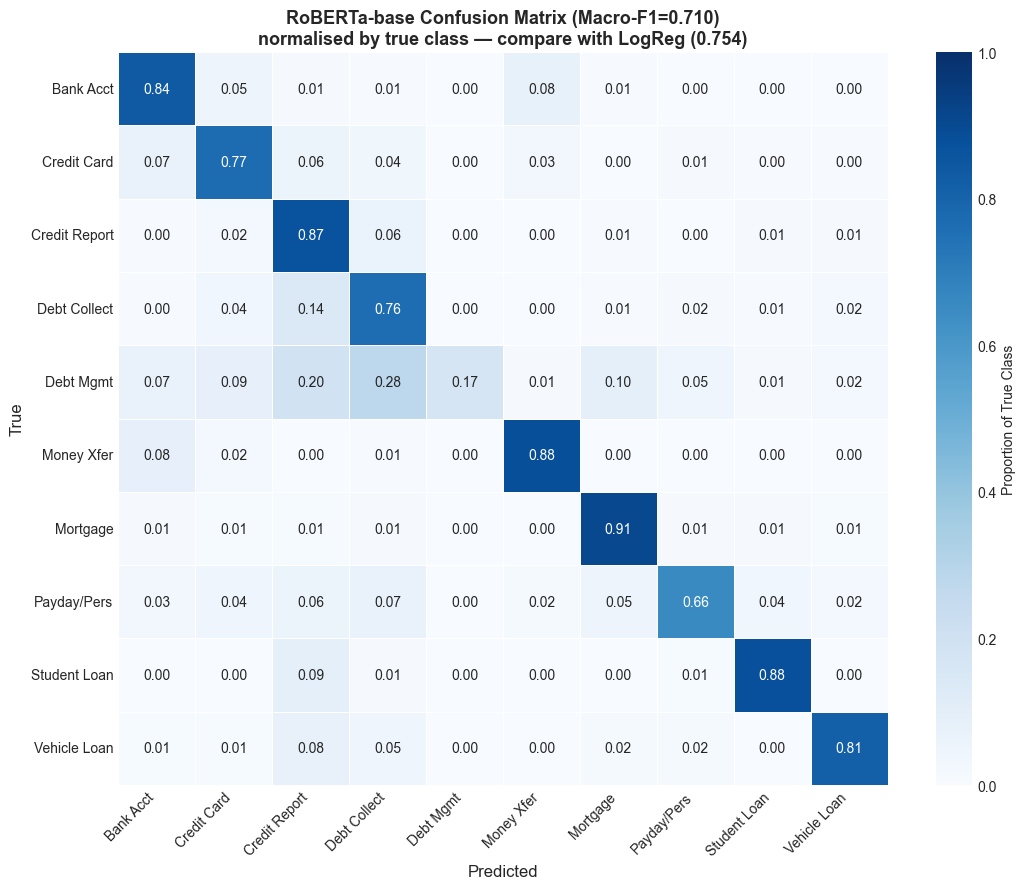

Top confused class pairs (off-diagonal > 0.05):
  Debt Mgmt       → Debt Collect     28.0%  🔴 SEVERE
  Debt Mgmt       → Credit Report    19.5%  🔴 SEVERE
  Debt Collect    → Credit Report    14.4%  🟡 Notable
  Debt Mgmt       → Mortgage         9.8%  🟡 Notable
  Student Loan    → Credit Report    9.5%  🟡 Notable
  Debt Mgmt       → Credit Card      8.5%  🟡 Notable
  Money Xfer      → Bank Acct        8.3%  🟡 Notable
  Bank Acct       → Money Xfer       8.0%  
  Vehicle Loan    → Credit Report    7.7%  
  Debt Mgmt       → Bank Acct        7.3%  
  Payday/Pers     → Debt Collect     7.3%  
  Credit Card     → Bank Acct        7.3%  
  Credit Report   → Debt Collect     6.5%  
  Credit Card     → Credit Report    6.1%  
  Payday/Pers     → Credit Report    5.8%  
  Payday/Pers     → Mortgage         5.3%  
  Bank Acct       → Credit Card      5.1%  


In [13]:
cm = confusion_matrix(y_true, y_pred, normalize="true")

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    cm, annot=True, fmt=".2f",
    xticklabels=short_labels, yticklabels=short_labels,
    cmap="Blues", ax=ax, linewidths=0.5, linecolor="white",
    vmin=0, vmax=1.0,
    cbar_kws={"label": "Proportion of True Class"},
)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title(
    f"RoBERTa-base Confusion Matrix (Macro-F1={macro_f1:.3f})\n"
    f"normalised by true class — compare with LogReg (0.754)",
    fontsize=13, fontweight="bold",
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "roberta_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top confused class pairs (off-diagonal > 0.05):")
confused = []
for i in range(n_classes):
    for j in range(n_classes):
        if i != j and cm[i, j] > 0.05:
            confused.append((cm[i, j], short_labels[i], short_labels[j]))
confused.sort(reverse=True)
for rate, true_cls, pred_cls in confused:
    severity = "🔴 SEVERE" if rate > 0.15 else "🟡 Notable" if rate > 0.08 else ""
    print(f"  {true_cls:15s} → {pred_cls:15s}  {rate:.1%}  {severity}")

## 10 · Multi-Model Comparison: LogReg vs ModernBERT vs RoBERTa

In [15]:
# ─── Load prior results ───
logreg_results_path = PROCESSED / "class_separability_analysis.json"
modernbert_results_path = ROOT / "models" / "modernbert_base" / "modernbert_results.json"

if logreg_results_path.exists():
    with open(logreg_results_path) as f:
        logreg_data = json.load(f)
    logreg_f1 = logreg_data["per_class_f1_logreg"]
    logreg_macro = logreg_data["logreg_macro_f1"]
else:
    logreg_f1 = {sl: None for sl in short_labels}
    logreg_macro = 0.7543

if modernbert_results_path.exists():
    with open(modernbert_results_path) as f:
        modernbert_data = json.load(f)
    modernbert_f1 = modernbert_data["per_class_f1"]
    modernbert_macro = modernbert_data["macro_f1"]
else:
    modernbert_f1 = {sl: None for sl in short_labels}
    modernbert_macro = None

roberta_per_class_f1 = f1_score(y_true, y_pred, average=None)

print(f"{'Class':15s}  {'LogReg':>8s}  {'ModBERT':>8s}  {'RoBERTa':>8s}  {'Best':>8s}")
print("-" * 62)
for i, sl in enumerate(short_labels):
    lr = logreg_f1.get(sl)
    mb = modernbert_f1.get(sl)
    rb = roberta_per_class_f1[i]

    vals = {}
    if lr is not None: vals["LogReg"] = lr
    if mb is not None: vals["ModBERT"] = mb
    vals["RoBERTa"] = rb

    best = max(vals, key=vals.get)
    lr_s = f"{lr:.3f}" if lr is not None else "N/A"
    mb_s = f"{mb:.3f}" if mb is not None else "N/A"
    print(f"{sl:15s}  {lr_s:>8s}  {mb_s:>8s}  {rb:>8.3f}  {best:>8s}")

print("-" * 62)
mb_macro_s = f"{modernbert_macro:.4f}" if modernbert_macro is not None else "N/A"
print(f"{'Macro':15s}  {logreg_macro:>8.4f}  {mb_macro_s:>8s}  {macro_f1:>8.4f}")

Class              LogReg   ModBERT   RoBERTa      Best
--------------------------------------------------------------
Bank Acct           0.777     0.806     0.819   RoBERTa
Credit Card         0.747     0.706     0.704    LogReg
Credit Report       0.731     0.913     0.908   ModBERT
Debt Collect        0.672     0.706     0.706   RoBERTa
Debt Mgmt           0.474     0.210     0.269    LogReg
Money Xfer          0.838     0.876     0.887   RoBERTa
Mortgage            0.906     0.836     0.830    LogReg
Payday/Pers         0.693     0.549     0.582    LogReg
Student Loan        0.894     0.740     0.737    LogReg
Vehicle Loan        0.811     0.654     0.653    LogReg
--------------------------------------------------------------
Macro              0.7543    0.6996    0.7097


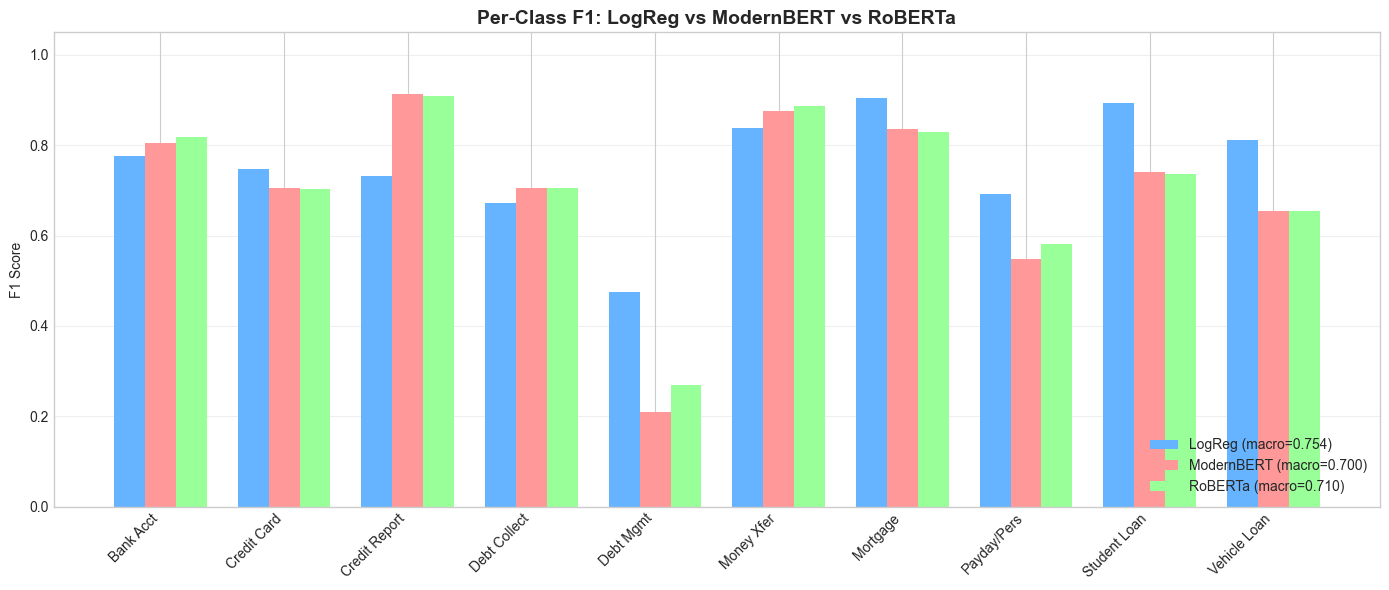

In [16]:
# ─── Grouped bar chart ───
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(n_classes)
width = 0.25

lr_vals = [logreg_f1.get(sl, 0) or 0 for sl in short_labels]
ax.bar(x - width, lr_vals, width, label=f"LogReg (macro={logreg_macro:.3f})", color="#66b3ff")

if modernbert_macro is not None:
    mb_vals = [modernbert_f1.get(sl, 0) or 0 for sl in short_labels]
    ax.bar(x, mb_vals, width, label=f"ModernBERT (macro={modernbert_macro:.3f})", color="#ff9999")
else:
    ax.bar(x, [0]*n_classes, width, label="ModernBERT (not yet run)", color="#ff9999", alpha=0.3)

ax.bar(x + width, roberta_per_class_f1, width, label=f"RoBERTa (macro={macro_f1:.3f})", color="#99ff99")

ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=45, ha="right")
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1.05)
ax.set_title("Per-Class F1: LogReg vs ModernBERT vs RoBERTa", fontsize=14, fontweight="bold")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "three_way_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 10b · Training Curves

Four-panel view: training loss, validation loss, validation Macro-F1, and learning rate schedule.

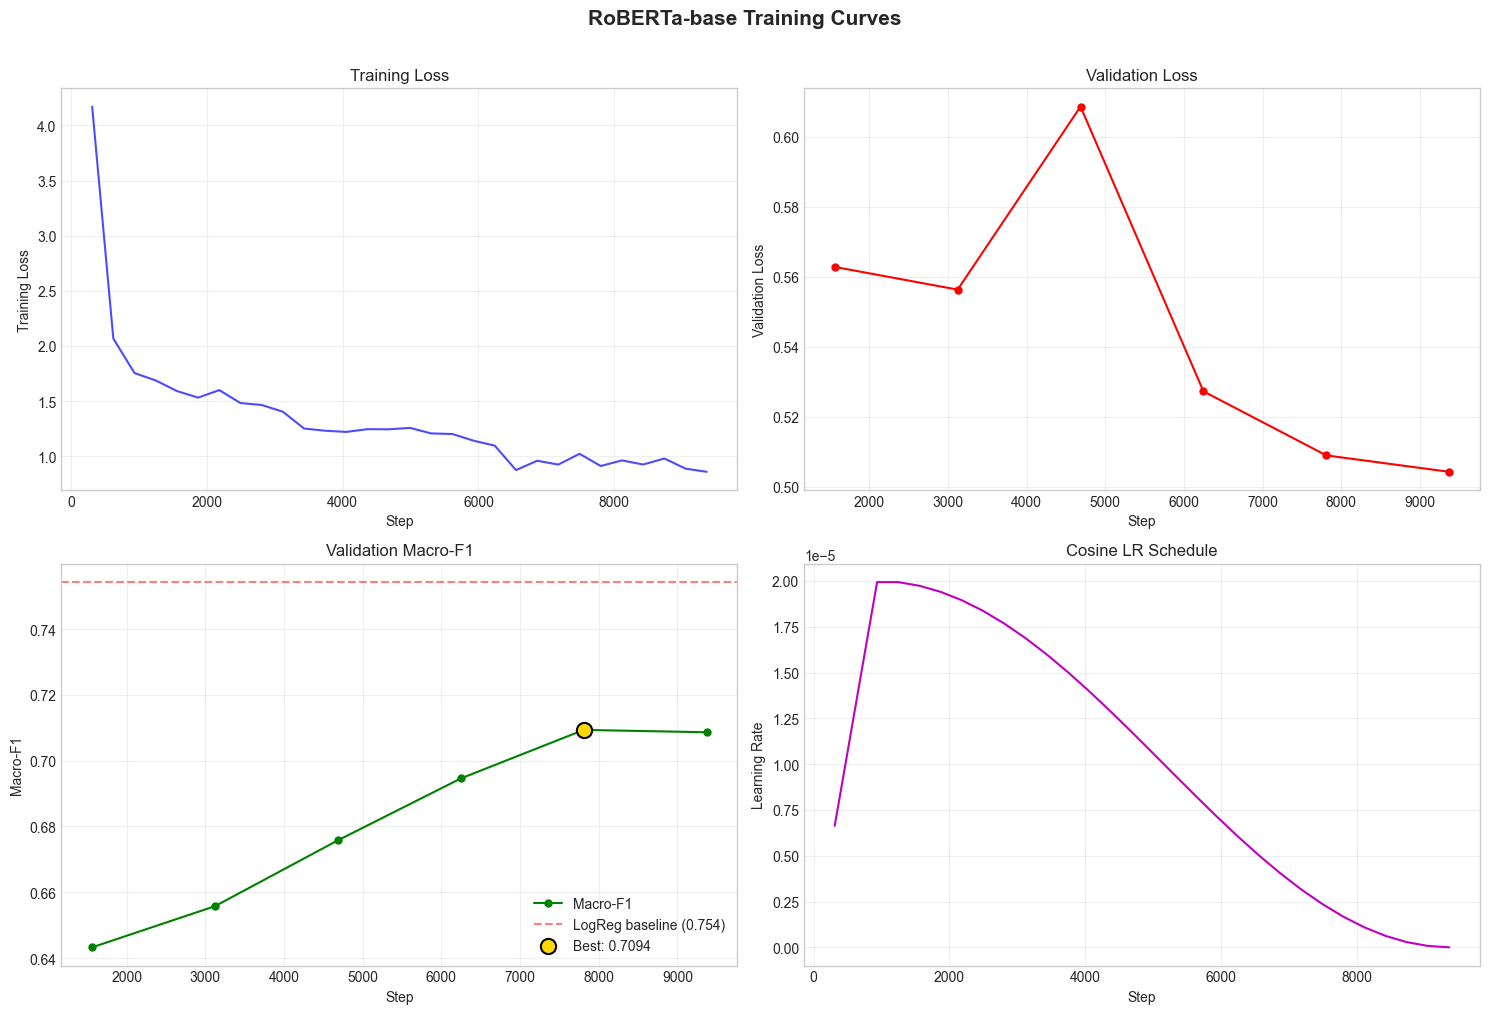


Training curve summary:
  Eval checkpoints:  6
  Best Macro-F1:     0.7094 (step 1560)
  Final Macro-F1:    0.7086 (step 9360)
  F1 delta (last 2): -0.0007


In [17]:
train_logs = [l for l in trainer.state.log_history if "loss" in l and "eval_loss" not in l]
eval_logs  = [l for l in trainer.state.log_history if "eval_macro_f1" in l]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# ── Panel 1: Training Loss ──
ax = axes[0, 0]
if train_logs:
    steps = [l["step"] for l in train_logs]
    losses = [l["loss"] for l in train_logs]
    ax.plot(steps, losses, "b-", alpha=0.7, linewidth=1.5)
    ax.set_xlabel("Step")
    ax.set_ylabel("Training Loss")
    ax.set_title("Training Loss")
    ax.grid(True, alpha=0.3)

# ── Panel 2: Validation Loss ──
ax = axes[0, 1]
if eval_logs:
    steps = [l["step"] for l in eval_logs]
    eval_losses = [l["eval_loss"] for l in eval_logs]
    ax.plot(steps, eval_losses, "r-o", markersize=5, linewidth=1.5)
    ax.set_xlabel("Step")
    ax.set_ylabel("Validation Loss")
    ax.set_title("Validation Loss")
    ax.grid(True, alpha=0.3)

# ── Panel 3: Validation Macro-F1 ──
ax = axes[1, 0]
if eval_logs:
    steps = [l["step"] for l in eval_logs]
    f1s = [l["eval_macro_f1"] for l in eval_logs]
    ax.plot(steps, f1s, "g-o", markersize=5, linewidth=1.5, label="Macro-F1")
    ax.axhline(y=0.7543, color="red", linestyle="--", alpha=0.5, label="LogReg baseline (0.754)")
    # Mark best checkpoint
    best_idx = np.argmax(f1s)
    ax.scatter([steps[best_idx]], [f1s[best_idx]], color="gold", s=120, zorder=5,
               edgecolors="black", linewidths=1.5, label=f"Best: {f1s[best_idx]:.4f}")
    ax.set_xlabel("Step")
    ax.set_ylabel("Macro-F1")
    ax.set_title("Validation Macro-F1")
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)

# ── Panel 4: Learning Rate Schedule ──
ax = axes[1, 1]
lr_logs = [l for l in trainer.state.log_history if "learning_rate" in l]
if lr_logs:
    steps = [l["step"] for l in lr_logs]
    lrs = [l["learning_rate"] for l in lr_logs]
    ax.plot(steps, lrs, "m-", linewidth=1.5)
    ax.set_xlabel("Step")
    ax.set_ylabel("Learning Rate")
    ax.set_title("Cosine LR Schedule")
    ax.grid(True, alpha=0.3)

plt.suptitle("RoBERTa-base Training Curves", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "roberta_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Summary stats ──
if eval_logs:
    print(f"\nTraining curve summary:")
    print(f"  Eval checkpoints:  {len(eval_logs)}")
    print(f"  Best Macro-F1:     {max(f1s):.4f} (step {steps[np.argmax(f1s)]})")
    print(f"  Final Macro-F1:    {f1s[-1]:.4f} (step {steps[-1]})")
    if len(f1s) >= 2:
        print(f"  F1 delta (last 2): {f1s[-1] - f1s[-2]:+.4f}")

## 10c · Training Loss vs Validation Loss (Overfitting Check)

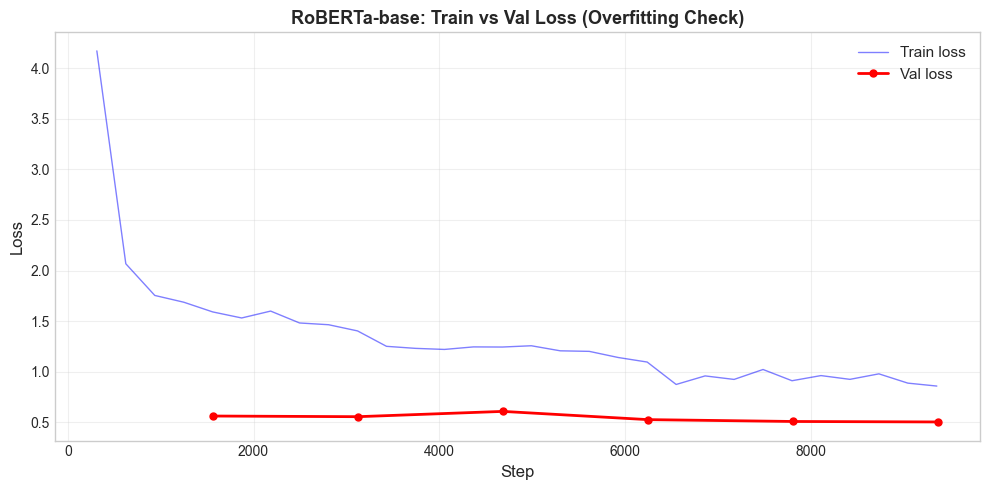

✓  Val loss trend: -0.0047 — no overfitting detected


In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

if train_logs:
    t_steps = [l["step"] for l in train_logs]
    t_losses = [l["loss"] for l in train_logs]
    ax.plot(t_steps, t_losses, "b-", alpha=0.5, linewidth=1, label="Train loss")

if eval_logs:
    e_steps = [l["step"] for l in eval_logs]
    e_losses = [l["eval_loss"] for l in eval_logs]
    ax.plot(e_steps, e_losses, "r-o", markersize=5, linewidth=2, label="Val loss")

ax.set_xlabel("Step", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title("RoBERTa-base: Train vs Val Loss (Overfitting Check)", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "roberta_overfit_check.png", dpi=150, bbox_inches="tight")
plt.show()

if eval_logs and len(eval_logs) >= 2:
    val_trend = e_losses[-1] - e_losses[-2]
    if val_trend > 0.01:
        print(f"⚠️  Val loss increased by {val_trend:.4f} — possible overfitting")
    else:
        print(f"✓  Val loss trend: {val_trend:+.4f} — no overfitting detected")

## 11 · Save Outputs

In [19]:
best_model_dir = OUTPUT_DIR / "best_model"
trainer.save_model(str(best_model_dir))
tokenizer.save_pretrained(str(best_model_dir))
print(f"Best model saved: {best_model_dir}")

results = {
    "model": MODEL_NAME,
    "max_seq_len": MAX_SEQ_LEN,
    "train_samples": len(train_dataset),
    "val_samples": len(val_dataset),
    "epochs": NUM_EPOCHS,
    "effective_batch_size": BATCH_SIZE * GRAD_ACCUM,
    "learning_rate": LEARNING_RATE,
    "precision": "bf16" if USE_BF16 else "fp16",
    "macro_f1": float(macro_f1),
    "micro_f1": float(micro_f1),
    "weighted_f1": float(weighted),
    "accuracy": float(accuracy),
    "per_class_f1": {sl: float(roberta_per_class_f1[i]) for i, sl in enumerate(short_labels)},
    "confusion_matrix_normalised": cm.tolist(),
    "training_time_min": round(elapsed / 60, 1),
    "logreg_macro_f1_baseline": logreg_macro,
    "modernbert_macro_f1_baseline": modernbert_macro,
}

results_path = OUTPUT_DIR / "roberta_results.json"
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)
print(f"Results saved: {results_path}")
print(f"Figures saved: {FIG_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\models\roberta_base\best_model
Results saved: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\models\roberta_base\roberta_results.json
Figures saved: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\reports\figures\nb04c


In [20]:
del model, trainer
gc.collect()
torch.cuda.empty_cache()
print("GPU memory released.")
print()
print("All baselines so far:")
print(f"  LogReg     Macro-F1: {logreg_macro:.4f}")
if modernbert_macro is not None:
    print(f"  ModernBERT Macro-F1: {modernbert_macro:.4f}")
print(f"  RoBERTa    Macro-F1: {macro_f1:.4f}")

GPU memory released.

All baselines so far:
  LogReg     Macro-F1: 0.7543
  ModernBERT Macro-F1: 0.6996
  RoBERTa    Macro-F1: 0.7097
